# Topic / Intent Classification

This notebook evaluates two approaches for analyzing customer support ticket themes.

First, the existing ticket categories are evaluated as labels for a supervised text classification approach using ticket descriptions as the primary text input.

Because the supervised baseline does not generalize effectively to unseen tickets, BERTopic is then used to discover latent themes directly from the ticket descriptions without relying on the existing ticket type labels.

The final output contains:

- `ticket_id`
- `topic_id`
- `topic_label`

In [1]:
# Imports & Dependencies
# Core libraries for data manipulation, NLP vectorization, and model evaluation
from pathlib import Path

import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    CountVectorizer,
    ENGLISH_STOP_WORDS
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

from bertopic import BERTopic

In [2]:
# Define the project root and processed dataset path.
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_support_tickets_cleaned.csv"
)

# Load the cleaned ticket dataset.
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (8469, 20)


,Ticket ID,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Cleaned Ticket Description,Has First Response,Is Resolved,Has CSAT,is_dissatisfied
0,1,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,I'm having an issue with the GoPro Hero. Pleas...,1,0,0,NaN
1,2,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,I'm having an issue with the LG Smart TV. Plea...,1,0,0,NaN
2,3,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,I'm facing a problem with my Dell XPS. The Del...,1,1,1,0.0
3,4,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,I'm having an issue with the Microsoft Office....,1,1,1,0.0
4,5,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,I'm having an issue with the Autodesk AutoCAD....,1,1,1,1.0


## 1. Inspecting Available Topic Labels

The dataset contains existing ticket metadata that may serve as weak labels for supervised topic classification.

Before selecting the modeling approach, the following fields are inspected:

- `Ticket Type`
- `Ticket Subject`
- `Cleaned Ticket Description`

The goal is to determine whether `Ticket Type` provides meaningful, sufficiently represented categories for a supervised classifier.

In [3]:
# Select the fields used to evaluate the supervised classification approach.
label_columns = [
    "Ticket Type",
    "Ticket Subject",
    "Cleaned Ticket Description"
]

df[label_columns].info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Ticket Type                 8469 non-null   str  
 1   Ticket Subject              8469 non-null   str  
 2   Cleaned Ticket Description  8469 non-null   str  
dtypes: str(3)
memory usage: 198.6 KB


In [4]:
# Check the number of tickets assigned to each ticket type.
print("Ticket Type distribution:")

display(
    df["Ticket Type"]
    .value_counts(dropna=False)
    .to_frame(name="count")
)

Ticket Type distribution:


,count
Ticket Type,
Refund request,1752
Technical issue,1747
Cancellation request,1695
Product inquiry,1641
Billing inquiry,1634


In [5]:
# Calculate the percentage distribution of each ticket type.
print("Ticket Type percentages:")

display(
    (
        df["Ticket Type"]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
        .to_frame(name="percentage")
    )
)

Ticket Type percentages:


,percentage
Ticket Type,
Refund request,20.69
Technical issue,20.63
Cancellation request,20.01
Product inquiry,19.38
Billing inquiry,19.29


In [6]:
# Review sample records to assess the relationship between ticket type,
# ticket subject, and the cleaned ticket description.
display(
    df[
        [
            "Ticket Type",
            "Ticket Subject",
            "Cleaned Ticket Description"
        ]
    ]
    .sample(10, random_state=42)
)

,Ticket Type,Ticket Subject,Cleaned Ticket Description
4830,Refund request,Product setup,I'm having an issue with the Roomba Robot Vacu...
7075,Product inquiry,Battery life,I'm having trouble connecting my Roomba Robot ...
4715,Billing inquiry,Refund request,I'm having an issue with the Philips Hue Light...
2022,Billing inquiry,Peripheral compatibility,I'm having an issue with the LG OLED. Please a...
676,Refund request,Peripheral compatibility,I'm having an issue with the Roomba Robot Vacu...
2283,Refund request,Refund request,I've encountered a data loss issue with my Son...
5076,Product inquiry,Software bug,I'm having an issue with the Sony 4K HDR TV. P...
2476,Refund request,Installation support,I'm having an issue with the Xbox. Please assi...
6847,Refund request,Hardware issue,I'm encountering a software bug in the Microso...
511,Product inquiry,Battery life,I'm having an issue with the Canon EOS. Please...


## 2. Modeling Decision

`Ticket Type` is selected as the target for supervised topic and intent classification.

The field contains five meaningful ticket categories, has no missing values, and shows a balanced class distribution. `Ticket Subject` is retained for reference only because the sampled records show that it does not consistently align with the target category.

`Cleaned Ticket Description` will be used as the primary text input for classification.

A supervised baseline using TF-IDF features and Logistic Regression will be evaluated using a stratified train-test split.

## 3. Data Preparation

The cleaned ticket description is used as the input text, and `Ticket Type` is used as the target label.

The data is split into training and test sets using stratification to preserve the ticket type distribution across both sets.

In [7]:
# Define the text feature and target label.
X = df["Cleaned Ticket Description"]
y = df["Ticket Type"]

# Split the data while preserving the class distribution in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (6775,)
Test set shape: (1694,)


In [8]:
# Compare class distributions across the full, training, and test datasets.
class_distribution = pd.DataFrame(
    {
        "full_dataset": y.value_counts(normalize=True),
        "training_set": y_train.value_counts(normalize=True),
        "test_set": y_test.value_counts(normalize=True)
    }
).mul(100).round(2)

class_distribution

,full_dataset,training_set,test_set
Ticket Type,,,
Refund request,20.69,20.68,20.72
Technical issue,20.63,20.63,20.60
Cancellation request,20.01,20.01,20.01
Product inquiry,19.38,19.38,19.36
Billing inquiry,19.29,19.29,19.30


## 4. Baseline Classification Model

A TF-IDF vectorizer converts the cleaned ticket descriptions into numerical features based on term importance.

A Logistic Regression classifier is then trained to predict the ticket type from the text features.

In [9]:
# Convert ticket descriptions into TF-IDF features.
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training feature matrix shape: {X_train_tfidf.shape}")
print(f"Test feature matrix shape: {X_test_tfidf.shape}")

Training feature matrix shape: (6775, 9477)
Test feature matrix shape: (1694, 9477)


In [10]:
# Train the classifier using the TF-IDF text features.
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [11]:
# Generate ticket type predictions for the held-out test set.
y_pred = model.predict(X_test_tfidf)

## 5. Model Evaluation

The baseline model is evaluated on the held-out test set using accuracy, class-level precision, recall, and F1-score.

A confusion matrix is also used to identify which ticket types are most frequently confused with one another.

In [12]:
# Evaluate the baseline model on the held-out test set.
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.2001

Classification Report:
                      precision    recall  f1-score   support

     Billing inquiry       0.22      0.20      0.21       327
Cancellation request       0.20      0.20      0.20       339
     Product inquiry       0.19      0.17      0.18       328
      Refund request       0.19      0.21      0.20       351
     Technical issue       0.21      0.22      0.21       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



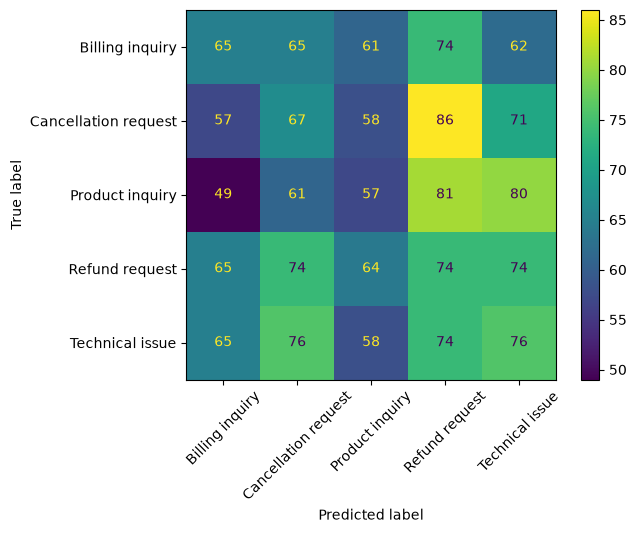

In [13]:
# Visualize classification performance across ticket types.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
);

In [14]:
# Compare training and test performance.
train_accuracy = model.score(X_train_tfidf, y_train)
test_accuracy = model.score(X_test_tfidf, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:     {test_accuracy:.4f}")

Training Accuracy: 0.6452
Test Accuracy:     0.2001


In [15]:
# Inspect sample predictions against the original ticket text.
comparison = pd.DataFrame({
    "ticket_text": X_test,
    "actual_label": y_test,
    "predicted_label": y_pred
})

comparison.sample(10, random_state=42)

,ticket_text,actual_label,predicted_label
3269,There seems to be a glitch in the Microsoft Of...,Technical issue,Billing inquiry
2258,I'm having an issue with the Roomba Robot Vacu...,Cancellation request,Product inquiry
4215,I'm having an issue with the LG OLED. Please a...,Billing inquiry,Cancellation request
7829,I'm having an issue with the Sony Xperia. Plea...,Refund request,Product inquiry
1762,I'm facing issues logging into my Roomba Robot...,Refund request,Refund request
8229,I'm having an issue with the Canon EOS. Please...,Cancellation request,Product inquiry
1185,I'm unable to access my Xbox account. It keeps...,Billing inquiry,Product inquiry
6379,I'm facing a problem with my GoPro Hero. The G...,Product inquiry,Technical issue
7754,I'm having an issue with the Samsung Soundbar....,Refund request,Billing inquiry
1378,I'm having an issue with the GoPro Hero. Pleas...,Cancellation request,Refund request


In [16]:
# Verify that predictions were generated from the current model and test matrix.
y_pred_check = model.predict(X_test_tfidf)

print("Predictions match:", np.array_equal(y_pred, y_pred_check))
print(
    "Test accuracy:",
    accuracy_score(y_test, y_pred_check)
)

Predictions match: True
Test accuracy: 0.2001180637544274


## 6. Unsupervised Topic Discovery

The supervised classification baseline did not generalize effectively to the held-out test set, achieving accuracy close to the random baseline for five balanced classes.

Therefore, BERTopic is used to discover latent themes directly from ticket descriptions without relying on the existing ticket type labels.

### 6.1 Preparing Text for Topic Discovery

The ticket descriptions contain some source-level artifacts, including unresolved placeholders, markup, URLs, email addresses, and scraped website content.

A separate text representation is created specifically for topic modeling so that the cleaned dataset used elsewhere in the project remains unchanged.

The preprocessing is intentionally conservative. Rather than attempting to manually remove every noisy or unrelated text fragment, only clearly identifiable artifacts and boilerplate are removed. This reduces noise while preserving the underlying customer support language.

In [17]:
# Create a topic-modeling-specific copy of the cleaned ticket descriptions.
topic_text = df["Cleaned Ticket Description"].fillna("").astype(str)


def clean_topic_text(text):
    """Prepare ticket descriptions for topic discovery."""

    # Remove HTML-like markup.
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove URLs and email addresses.
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\b\S+@\S+\.\S+\b", " ", text)

    # Remove unresolved template expressions and placeholders.
    text = re.sub(r"\{[^}]*\}", " ", text)
    text = re.sub(
        r"\bproduct_purch(?:ased)?\b|\bproduct_name\b",
        " ",
        text,
        flags=re.IGNORECASE
    )

    # Remove repeated generic support phrases.
    generic_patterns = [
        r"\bi'?m having an issue with (?:the|my)?\b",
        r"\bi'?m facing a problem with (?:the|my)?\b",
        r"\bplease assist\b",
        r"\bplease help\b",
        r"\bthank you\b",
        r"\bthanks\b"
    ]

    for pattern in generic_patterns:
        text = re.sub(
            pattern,
            " ",
            text,
            flags=re.IGNORECASE
        )

    # Remove clearly identifiable scraped or code-related artifacts.
    artifact_patterns = [
        r"please enable javascript to view the comments powered by disqus",
        r"comments powered by disqus",
        r"\b(?:std|void|include|stdioh|fuser)\b",
        r"xda-developer"
    ]

    for pattern in artifact_patterns:
        text = re.sub(
            pattern,
            " ",
            text,
            flags=re.IGNORECASE
        )

    # Normalize whitespace.
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Apply general preprocessing.
topic_text = topic_text.apply(clean_topic_text)


# Remove product names so clustering focuses on support issues.
product_names = (
    df["Product Purchased"]
    .dropna()
    .astype(str)
    .sort_values(
        key=lambda values: values.str.len(),
        ascending=False
    )
    .unique()
)

for product in product_names:
    topic_text = topic_text.str.replace(
        re.escape(product),
        " ",
        case=False,
        regex=True
    )


# Perform final text normalization.
topic_text = (
    topic_text
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)


# Store the topic-modeling text separately.
df["Topic Modeling Text"] = topic_text

### 6.2 Validating Topic Modeling Input

The topic-modeling text is checked to confirm that preprocessing did not create empty documents before fitting the BERTopic model.

In [18]:
# Create the final document collection for topic modeling.
topic_documents = (
    df["Topic Modeling Text"]
    .fillna("")
    .astype(str)
    .tolist()
)

print(f"Number of documents: {len(topic_documents)}")

print(
    "Empty documents:",
    sum(not document.strip() for document in topic_documents)
)

# Review a sample of the processed ticket text.
display(
    df[
        [
            "Ticket ID",
            "Cleaned Ticket Description",
            "Topic Modeling Text"
        ]
    ]
    .sample(10, random_state=42)
)

Number of documents: 8469
Empty documents: 0


,Ticket ID,Cleaned Ticket Description,Topic Modeling Text
4830,4831,I'm having an issue with the Roomba Robot Vacu...,. . I'm using for something different. If ther...
7075,7076,I'm having trouble connecting my Roomba Robot ...,I'm having trouble connecting my to my home Wi...
4715,4716,I'm having an issue with the Philips Hue Light...,. . Please give credit to: @joeyclay I'm conce...
2022,2023,I'm having an issue with the LG OLED. Please a...,. . 4. Check and compare product pricing You w...
676,677,I'm having an issue with the Roomba Robot Vacu...,. . I would like my price to rise so that I ca...
2283,2284,I've encountered a data loss issue with my Son...,I've encountered a data loss issue with my . A...
5076,5077,I'm having an issue with the Sony 4K HDR TV. P...,. . I've noticed a peculiar error message popp...
2476,2477,I'm having an issue with the Xbox. Please assi...,. . If you are having trouble with your packag...
6847,6848,I'm encountering a software bug in the Microso...,I'm encountering a software bug in the . Whene...
511,512,I'm having an issue with the Canon EOS. Please...,". . , and a lot, I've tried clearing the cache..."


### 6.3 Configuring Topic Representation

BERTopic uses a vectorizer to generate the words and phrases that describe each topic.

Additional domain-generic support terms are added to the default English stopword list so that broad conversational language does not dominate the topic representations. Meaningful support concepts such as account, battery, data, software, and update are retained.

Both unigrams and bigrams are used so that phrases such as `battery life`, `software bug`, and `data loss` can contribute to topic interpretation.

In [19]:
custom_stopwords = ENGLISH_STOP_WORDS.union(
    {
        "issue",
        "issues",
        "ive",
        "im",
        "please",
        "assist",
        "help",
        "problem",
        "problems",
        "product",
        "purchased",
        "purchase",
        "having",
        "facing"
    }
)

print(f"Number of custom stopwords: {len(custom_stopwords)}")

Number of custom stopwords: 331


In [20]:
vectorizer_model = CountVectorizer(
    stop_words=list(custom_stopwords),
    ngram_range=(1, 2),
    min_df=5
)

### 6.4 Fitting the Topic Model

BERTopic is fitted to the refined ticket descriptions using the custom vectorizer.

The model discovers groups of semantically similar tickets without using the existing `Ticket Type` labels.

In [21]:
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    verbose=True,
    calculate_probabilities=False
)

topics, probabilities = topic_model.fit_transform(
    topic_documents
)

2026-09-10 14:22:19,215 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/265 [00:00<?, ?it/s]

2026-09-10 14:23:23,915 - BERTopic - Embedding - Completed ✓
2026-09-10 14:23:23,917 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-10 14:23:46,497 - BERTopic - Dimensionality - Completed ✓
2026-09-10 14:23:46,499 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-10 14:23:46,683 - BERTopic - Cluster - Completed ✓
2026-09-10 14:23:46,683 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-10 14:23:46,926 - BERTopic - Representation - Completed ✓


### 6.5 Inspecting Discovered Topics

The discovered topics are reviewed using their ticket counts, representative keywords, and representative ticket descriptions.

Topic quality is evaluated based on semantic coherence rather than targeting a predetermined number of topics.

In [22]:
topic_info = topic_model.get_topic_info()

print(f"Number of discovered topics: {len(topic_info)}")

topic_info.head(20)

Number of discovered topics: 128


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2028,-1_times_works fine_intermittent works_unexpec...,"[times, works fine, intermittent works, unexpe...",[. . Product Purchased Product Purchased Produ...
1,0,313,0_updated firmware_firmware started_afterward ...,"[updated firmware, firmware started, afterward...",[. . I am still having problems with the produ...
2,1,208,1_action guide_option perform_guide steps_perf...,"[action guide, option perform, guide steps, pe...",[. . Product Price: $33.00 I'm unable to find ...
3,2,193,2_decrease battery_life used_noticed sudden_su...,"[decrease battery, life used, noticed sudden, ...",[. . ! . Sonic Cyanide Powder-Energizer Hands-...
4,3,182,3_charger_charging properly_came charging_orig...,"[charger, charging properly, came charging, or...",[. . . . { I'm using the original charger that...
5,4,164,4_retrieve_loss_files_guide,"[retrieve, loss, files, guide, data, different...",[I've encountered a data loss issue with my . ...
6,5,162,5_causing_errors_loss_software bug,"[causing, errors, loss, software bug, app, bug...",[I've noticed a software bug in the app. It's ...
7,6,160,6_says does_message popping_popping_peculiar e...,"[says does, message popping, popping, peculiar...",[. . Product is sold by Cafe Crave I've notice...
8,7,160,7_connection_internet_troubleshoot network_stable,"[connection, internet, troubleshoot network, s...",[The is unable to establish a stable internet ...
9,8,157,8_yesterday_working fine_doesnt respond_respond,"[yesterday, working fine, doesnt respond, resp...",[. The is not turning on. It was working fine ...


In [23]:
sample_topics = topic_info.loc[
    topic_info["Topic"] != -1,
    "Topic"
].head(10).tolist()

for topic_id in sample_topics:
    print(f"\n{'=' * 80}")
    print(f"Topic {topic_id}")
    print(f"{'=' * 80}")

    print("\nKeywords:")
    print(topic_model.get_topic(topic_id))

    print("\nRepresentative documents:")
    for document in topic_model.get_representative_docs(topic_id)[:3]:
        print(f"- {document}")


Topic 0

Keywords:
[('updated firmware', np.float64(0.06443294504671526)), ('firmware started', np.float64(0.06429025531556574)), ('afterward related', np.float64(0.06429025531556574)), ('afterward', np.float64(0.06429025531556574)), ('related update', np.float64(0.06429025531556574)), ('happening afterward', np.float64(0.06429025531556574)), ('started happening', np.float64(0.06429025531556574)), ('recently updated', np.float64(0.06421816856322621)), ('firmware', np.float64(0.0639321906364387)), ('happening', np.float64(0.06386096825075614))]

Representative documents:
- . . I am still having problems with the product. . I still have an issue. . I still have an issue with I've recently updated the firmware of my , and the issue started happening afterward. Could it be related to the update?
- . . :3) I've recently updated the firmware of my , and the issue started happening afterward. Could it be related to the update?
- . . I've recently updated the firmware of my , and the issue st

### 6.6 Evaluating Topic Size Distribution

In [24]:
# Examine the distribution of document counts across discovered topics.
topic_counts = topic_info.copy()

# Separate the outlier topic from regular topics.
regular_topics = topic_counts[
    topic_counts["Topic"] != -1
].copy()

print(f"Regular topics: {len(regular_topics)}")
print(f"Outlier documents: {topic_counts.loc[topic_counts['Topic'] == -1, 'Count'].iloc[0]}")

print("\nTopic size summary:")
display(
    regular_topics["Count"]
    .describe()
    .to_frame(name="topic_size")
)

Regular topics: 127
Outlier documents: 2028

Topic size summary:


,topic_size
count,127.000000
mean,50.716535
std,53.452085
min,10.000000
25%,15.000000
50%,29.000000
75%,56.500000
max,313.000000


In [25]:
# Group topics into size ranges to identify potential fragmentation.
topic_size_ranges = pd.cut(
    regular_topics["Count"],
    bins=[0, 10, 25, 50, 100, np.inf],
    labels=[
        "1–10 documents",
        "11–25 documents",
        "26–50 documents",
        "51–100 documents",
        "100+ documents"
    ]
)

topic_size_distribution = (
    topic_size_ranges
    .value_counts()
    .sort_index()
    .to_frame(name="number_of_topics")
)

topic_size_distribution

,number_of_topics
Count,
1–10 documents,1
11–25 documents,57
26–50 documents,31
51–100 documents,19
100+ documents,19


In [26]:
# Review the smallest topics to determine whether they represent
# meaningful support themes or fragmented/noisy clusters.
smallest_topics = (
    regular_topics[
        [
            "Topic",
            "Count",
            "Name",
            "Representation"
        ]
    ]
    .sort_values("Count")
    .head(20)
)

smallest_topics

,Topic,Count,Name,Representation
127,126,10,126_occurring recent_havent changes_changes de...,"[occurring recent, havent changes, changes dev..."
119,118,11,118_password_working recover_option working_fo...,"[password, working recover, option working, fo..."
124,123,11,123_password_password reset_account password_w...,"[password, password reset, account password, w..."
118,117,11,117_access account_access_account keeps_correc...,"[access account, access, account keeps, correc..."
125,124,11,124_deleted_deleted files_deleted important_im...,"[deleted, deleted files, deleted important, im..."
120,119,11,119_error_device reported_sure specific_specif...,"[error, device reported, sure specific, specif..."
123,122,11,122_internet_troubleshoot network_stable_conne...,"[internet, troubleshoot network, stable, conne..."
121,120,11,120_connecting_wifi_connecting fine_fine resolve,"[connecting, wifi, connecting fine, fine resol..."
122,121,11,121_updates fixes_fixes_crashes updates_bug try,"[updates fixes, fixes, crashes updates, bug tr..."
126,125,11,125_unable use_hardware_screen_security like,"[unable use, hardware, screen, security like, ..."


### 6.7 Reducing Topic Fragmentation

The initial BERTopic model identifies a large number of granular topics, including several small clusters that represent closely related customer support issues.

To produce a more interpretable analytical output, semantically similar topics are consolidated using BERTopic's topic reduction functionality.

The reduction is used to improve interpretability rather than to force the model into a predetermined number of categories.

In [27]:
# Record the number of regular topics before reduction.
regular_topics_before = (
    topic_model.get_topic_info()
    .query("Topic != -1")
    .shape[0]
)

print(f"Regular topics before reduction: {regular_topics_before}")

# Reduce fragmented topics while preserving the outlier topic (-1).
topic_model.reduce_topics(
    topic_documents,
    nr_topics=30
)

# Retrieve the reduced topic assignments.
reduced_topics = topic_model.topics_

# Inspect the reduced topic structure.
reduced_topic_info = topic_model.get_topic_info()

regular_topics_after = (
    reduced_topic_info
    .query("Topic != -1")
    .shape[0]
)

print(f"Regular topics after reduction: {regular_topics_after}")

reduced_topic_info.head(20)

2026-09-10 14:23:47,417 - BERTopic - Topic reduction - Reducing number of topics
2026-09-10 14:23:47,426 - BERTopic - Representation - Fine-tuning topics using representation models.


Regular topics before reduction: 127


2026-09-10 14:23:47,611 - BERTopic - Representation - Completed ✓
2026-09-10 14:23:47,611 - BERTopic - Topic reduction - Reduced number of topics from 128 to 30


Regular topics after reduction: 29


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2028,-1_times_device_software_works fine,"[times, device, software, works fine, works, f...",[. . Product Purchased Product Purchased Produ...
1,0,1753,0_started_update_happening_updated firmware,"[started, update, happening, updated firmware,...",[. . . I've recently updated the firmware of m...
2,1,474,1_account_password_access_login,"[account, password, access, login, logging, in...",[I'm unable to access my account. It keeps dis...
3,2,410,2_data_files_deleted_lost,"[data, files, deleted, lost, way, loss, import...",[I've accidentally deleted important data from...
4,3,335,3_order_id_troubleshooting steps_troubleshooting,"[order, id, troubleshooting steps, troubleshoo...",[. . */ $list - if (! $order) $('$customer-id'...
5,4,317,4_does mean_mean_says does_popping screen,"[does mean, mean, says does, popping screen, m...",[. . I've noticed a peculiar error message pop...
6,5,310,5_unable option_guide steps_option perform_per...,"[unable option, guide steps, option perform, p...",[. . . ! . for being a supporter! {product_p I...
7,6,275,6_connecting_home_trouble_network,"[connecting, home, trouble, network, devices, ...",[I'm having trouble connecting my to my home W...
8,7,219,7_productivity_affecting work_assistance soon_...,"[productivity, affecting work, assistance soon...",[. . . ! I need assistance as soon as possible...
9,8,199,8_safe_like ensure_concerned security_security...,"[safe, like ensure, concerned security, securi...",[. . I'm concerned about the security of my an...


### 6.8 Reviewing Reduced Topics

The reduced topic structure is inspected before assigning human-readable labels.

Each topic is reviewed using its size, keyword representation, and representative ticket descriptions. This step is necessary to determine whether the reduced topics represent coherent customer support themes and whether any broad topics require additional interpretation.

In [28]:
# Select all regular topics after reduction.
regular_topic_ids = reduced_topic_info.loc[
    reduced_topic_info["Topic"] != -1,
    "Topic"
].tolist()

# Review each reduced topic using its size, keywords,
# and representative ticket descriptions.
for topic_id in regular_topic_ids:
    topic_count = reduced_topic_info.loc[
        reduced_topic_info["Topic"] == topic_id,
        "Count"
    ].iloc[0]

    print(f"\n{'=' * 80}")
    print(f"Topic {topic_id} | Documents: {topic_count}")
    print(f"{'=' * 80}")

    print("\nKeywords:")
    print(topic_model.get_topic(topic_id))

    print("\nRepresentative documents:")
    for document in topic_model.get_representative_docs(topic_id)[:3]:
        print(f"- {document}")


Topic 0 | Documents: 1753

Keywords:
[('started', np.float64(0.026888351581252634)), ('update', np.float64(0.026850148123477073)), ('happening', np.float64(0.025209404727397307)), ('updated firmware', np.float64(0.025194355536577263)), ('related', np.float64(0.025152959762393897)), ('firmware started', np.float64(0.02512969810814532)), ('happening afterward', np.float64(0.02512969810814532)), ('afterward related', np.float64(0.02512969810814532)), ('afterward', np.float64(0.02512969810814532)), ('started happening', np.float64(0.02512969810814532))]

Representative documents:
- . . . I've recently updated the firmware of my , and the issue started happening afterward. Could it be related to the update?
- . . I've recently updated the firmware of my , and the issue started happening afterward. Could it be related to the update?
- . . for your input. I've recently updated the firmware of my , and the issue started happening afterward. Could it be related to the update?

Topic 1 | Docume

### 6.9 Assigning Human-Readable Topic Labels

The reduced BERTopic topics are assigned human-readable labels based on their keywords and representative ticket descriptions.

The outlier topic (`-1`) is retained and labeled separately as `Other or Unclassified Support Content` to distinguish tickets that were not assigned to a regular topic cluster.

The final topic output contains:

- `Ticket ID`
- `topic_id`
- `topic_label`

In [29]:
# Map reduced topic IDs to human-readable support themes.
topic_labels = {
    -1: "Other or Unclassified Support Content",
    0: "Issue After Firmware Update",
    1: "App Issue Persists After Troubleshooting",
    2: "Account Access and Password Issues",
    3: "Data Loss and File Recovery",
    4: "Error Messages and Error Codes",
    5: "Unable to Perform Desired Action",
    6: "Wi-Fi Connectivity Issues",
    7: "Security and Data Safety Concerns",
    8: "Charging Problems",
    9: "Battery Life Issues",
    10: "Unstable Internet Connection",
    11: "Software Bugs and Data Loss",
    12: "Application Crashes and Software Bugs",
    13: "General Hardware Malfunction",
    14: "Software Freezing Issues",
    15: "Software Update Availability",
    16: "Screen and Display Problems",
    17: "Urgent Issue Affecting Productivity",
    18: "Device Not Turning On",
    19: "Urgent Issue Affecting Productivity",
    20: "Repair or Replacement Concerns",
    21: "Refund Issues",
    22: "Invoice and Payment Issues",
    23: "Email and Account Issues",
    24: "Other Support Content",
    25: "Refund and Exchange Requests",
    26: "Other Support Content",
    27: "Other Support Content",
    28: "Other Support Content"
}

In [30]:
# Create the final topic classification output using reduced BERTopic assignments.
df_topics = df[["Ticket ID"]].copy()

df_topics["topic_id"] = pd.Series(
    reduced_topics,
    index=df_topics.index
).astype(int)

df_topics["topic_label"] = (
    df_topics["topic_id"]
    .map(topic_labels)
)

df_topics.head()

,Ticket ID,topic_id,topic_label
0,1,-1,Other or Unclassified Support Content
1,2,0,Issue After Firmware Update
2,3,15,Software Update Availability
3,4,0,Issue After Firmware Update
4,5,9,Battery Life Issues


### 6.10 Validating the Topic Output

The final topic output is validated to confirm that:

- each ticket has one topic assignment;
- all topic IDs have corresponding human-readable labels; and
- the number of output rows matches the original dataset.

In [31]:
# Validate the final topic classification output.
print(f"Rows in topic output: {len(df_topics):,}")
print(
    f"Missing topic labels: "
    f"{df_topics['topic_label'].isna().sum():,}"
)

print(
    f"Unique topic IDs: "
    f"{df_topics['topic_id'].nunique():,}"
)

df_topics.head(10)

Rows in topic output: 8,469
Missing topic labels: 0
Unique topic IDs: 30


,Ticket ID,topic_id,topic_label
0,1,-1,Other or Unclassified Support Content
1,2,0,Issue After Firmware Update
2,3,15,Software Update Availability
3,4,0,Issue After Firmware Update
4,5,9,Battery Life Issues
5,6,15,Software Update Availability
6,7,1,App Issue Persists After Troubleshooting
7,8,-1,Other or Unclassified Support Content
8,9,0,Issue After Firmware Update
9,10,14,Software Freezing Issues


### 6.11 Persisting the Topic Model

The reduced BERTopic model is persisted so that the same topic discovery
pipeline can be reused for local inference without retraining the model.

In [32]:
# Define the output path for the persisted BERTopic model.
TOPIC_MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "bertopic_support_topics"
)

# Create the model directory if it does not already exist.
TOPIC_MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

# Persist the reduced BERTopic model for local inference.
topic_model.save(
    TOPIC_MODEL_PATH,
    serialization="pickle"
)

print(f"Topic model saved to: {TOPIC_MODEL_PATH}")

2026-09-10 14:23:47,886 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Topic model saved to: c:\Users\roshi\DA_Sprint\projects\ai-customer-support-analytics\models\bertopic_support_topics


### 6.12 Spot-Checking Topic Assignments

A sample of tickets from selected topics is reviewed alongside their assigned human-readable labels.

This qualitative validation checks whether the discovered topics reasonably reflect the underlying customer support issue described in each ticket.

In [33]:
# Review sample tickets from selected topics for qualitative validation.
sample_topic_ids = [0, 2, 6, 9, 13, 20, 22, -1]

for topic_id in sample_topic_ids:
    print(f"\n{'=' * 80}")
    print(f"Topic {topic_id}: {topic_labels[topic_id]}")
    print(f"{'=' * 80}")

    sample_tickets = (
        df_topics[df_topics["topic_id"] == topic_id]
        .merge(
            df[
                [
                    "Ticket ID",
                    "Cleaned Ticket Description"
                ]
            ],
            on="Ticket ID",
            how="left"
        )
        .sample(
            min(3, (df_topics["topic_id"] == topic_id).sum()),
            random_state=42
        )
    )

    for _, row in sample_tickets.iterrows():
        print(f"\nTicket ID: {row['Ticket ID']}")
        print(row["Cleaned Ticket Description"])


Topic 0: Issue After Firmware Update

Ticket ID: 1506
I'm having an issue with the Dell XPS. Please assist. If you see something and feel the product in its intended way, please return it. Please check back frequently to see if items are in their expected I've performed a factory reset on my Dell XPS, hoping it would resolve the problem, but it didn't help.

Ticket ID: 1903
I'm having an issue with the Samsung Soundbar. Please assist. SMS, please assist! The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.

Ticket ID: 1891
I'm having an issue with the Nest Thermostat. Please assist. This problem started occurring after the recent software update. I haven't made any other changes to the device.

Topic 2: Account Access and Password Issues

Ticket ID: 3886
My Sony Xperia crashed, and I lost all the data stored on it. Is there any way to recover the lost data? I'm guessing it could do a few pieces of work (just the reseting of the databa

## 7. Exporting Topic Classification Results

The validated topic assignments are exported for use in the downstream dissatisfaction-risk modeling and KPI aggregation workflow.

The exported dataset contains one topic assignment and one human-readable topic label for each customer support ticket.

In [34]:
# Define the output path for the topic classification results.
TOPIC_OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_support_topics.csv"
)

# Export the validated topic assignments.
df_topics.to_csv(
    TOPIC_OUTPUT_PATH,
    index=False
)

print(f"Topic results saved to: {TOPIC_OUTPUT_PATH}")

Topic results saved to: c:\Users\roshi\DA_Sprint\projects\ai-customer-support-analytics\data\processed\customer_support_topics.csv


In [35]:
# Confirm that the exported topic results can be loaded successfully.
df_topics_check = pd.read_csv(TOPIC_OUTPUT_PATH)

print(f"Exported dataset shape: {df_topics_check.shape}")

print(
    "All topic assignments preserved:",
    len(df_topics_check) == len(df_topics)
)

print(
    "Missing topic labels:",
    df_topics_check["topic_label"].isna().sum()
)

df_topics_check.head()

Exported dataset shape: (8469, 3)
All topic assignments preserved: True
Missing topic labels: 0


,Ticket ID,topic_id,topic_label
0,1,-1,Other or Unclassified Support Content
1,2,0,Issue After Firmware Update
2,3,15,Software Update Availability
3,4,0,Issue After Firmware Update
4,5,9,Battery Life Issues


## 8. Summary and Limitations

The topic modeling pipeline assigns a topic to every customer support ticket
and provides a human-readable label for each discovered theme.

The resulting topics should be interpreted as exploratory support themes rather
than ground-truth categories. Manual spot-checking indicates that several topics
form coherent support themes, while others remain semantically mixed.

The source ticket descriptions contain templated language and residual scraped
or unrelated text, which can reduce topic purity and influence cluster
representations. As a result, some assigned labels describe the dominant theme
of a topic rather than every individual ticket within that cluster.

Despite these limitations, the reduced topic structure provides an additional
analytical dimension that can be integrated with sentiment and dissatisfaction-risk
features for downstream SQL analysis and dashboard reporting.